In [93]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
from scipy.linalg import toeplitz
import pywt as wt
from scipy.fft import fft, fftfreq

# MSE StatDig : Chap 9 "Adaptive filtering""
## Ex 9.3 Adaptive line enhancer using LMS
ver : DLY/11.05.2026

## General

### Description

This example shows how to apply adaptive filters to signal separation. In adaptive line enhancement, a measured signal s(n) contains two signals, an unknown signal of interest v(n), and a nearly-periodic noise signal p(n).
The goal is to remove the noise signal p(n) from the measured signal s(n) to obtain the signal of interest v(n).

### Work

#### Ex1 : Load the signal

- Load from the file ex93_AdaptiveLineEnhancer_LMS.wav. The file contains the data x and the frequency sampling Fe.

``` python
from scipy.io import wavfile
# Charger le fichier WAV
fs, signal = wavfile.read('ex93_AdaptiveLineEnhancer_LMS.wav')
```

- Normalize the signal to the range [-1, 1]
``` python
signal = signal / max(abs(signal))
```

- Create a shorter version which will be faster to compute. Example tmax = 3 seconds instead of 9 seconds of the original signal

- Hear the signal with sounddevice and display it with matplotlib

``` python
import sounddevice as sd
sd.play(signal_cut, fs)
sd.wait()  # Attendre que la lecture soit terminée
```



In [94]:
from scipy.io import wavfile
# Charger le fichier WAV
fs, signal_long = wavfile.read('ex93_AdaptiveLineEnhancer_LMS.wav')
signal_long = signal_long / max(abs(signal_long))
signal_cut = signal_long[:132000] #takes first 66k samples, ~3sec
import sounddevice as sd

sd.play(signal_cut, fs)
sd.wait()  # Attendre que la lecture soit terminée

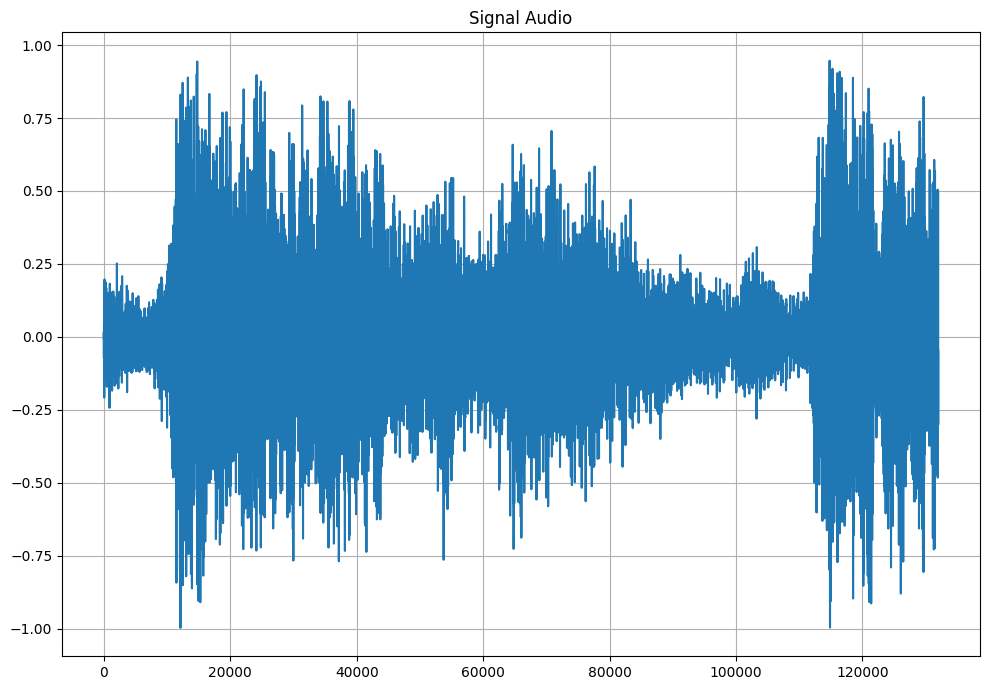

In [95]:
fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(1, 1, 1)
ax1.plot(signal_cut)
ax1.set_title('Signal Audio')
ax1.grid(True)

fig.tight_layout()
plt.show()

#### Ex2 : One frequency noise
The goal now is to add a periodic perturbation to the signal and to remove it with two methods : notch filter and lms adaptive filter

##### Ex2.1 : Generate the noise signal

- Generate a periodic noise signal p(n), a sinusoid with a frequency of 1000 Hz and an amplitude of 0.5
- Add this noise p(n) to the signal x(n) to create the measured signal s(n)
- Hear the noise and the noisy signal with sounddevice


In [96]:
# 1. Get the exact length of your existing signal
N = len(signal_cut)

# 2. Create a timeline that matches that exact number of points
# (Make sure 'fs' matches whatever sampling rate your signal_cut uses!)
fs = 44100 
t = np.arange(N) / fs

# 3. Generate the 1000Hz noise
f_noise = 1000
A_noise = 0.5
w_noise = 2 * np.pi * f_noise
p_n = A_noise * np.sin(w_noise * t)

# 4. Add them together
noisy_signal = signal_cut + p_n

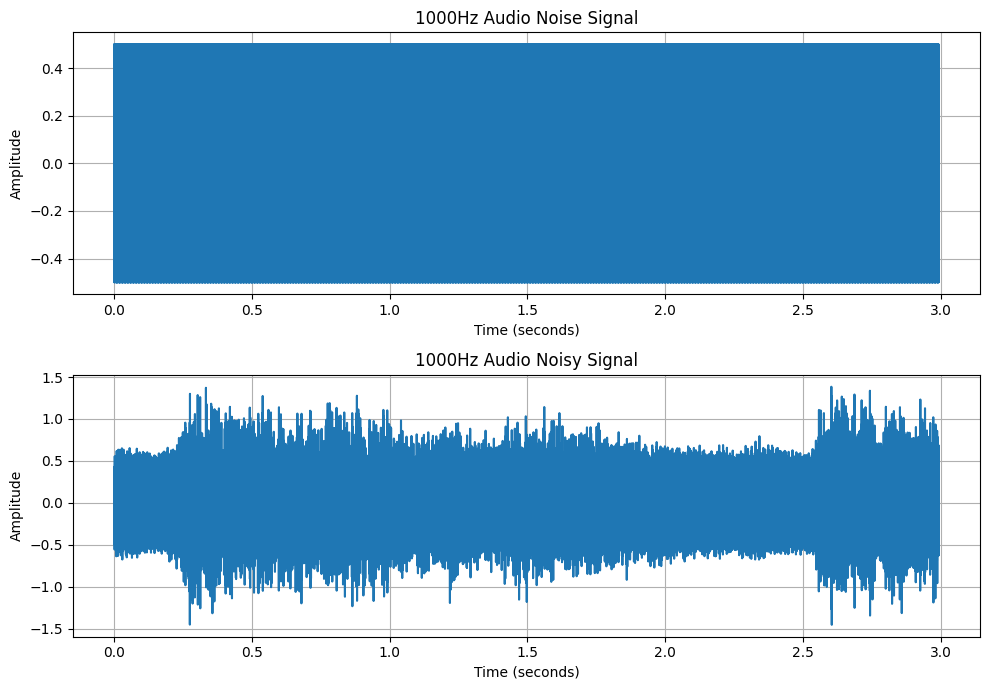

In [97]:
#Plot the signal
fig = plt.figure(figsize=(10, 7))
ax1 = fig.add_subplot(2, 1, 1)

ax1.plot(t, p_n)
ax1.set_title('1000Hz Audio Noise Signal')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Amplitude')
ax1.grid(True)

ax2 = fig.add_subplot(2, 1, 2)

ax2.plot(t, noisy_signal)
ax2.set_title('1000Hz Audio Noisy Signal')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Amplitude')
ax2.grid(True)

fig.tight_layout()
plt.show()

##### Ex2.2 : Stopband filter

As the noise p(n) is a single tone, it is very easy to remove it with a stopband filter.

- Analyse the noisy signal in the frequency domain
- Design a stopband filter to remove the noise
- Filter the signal with the notch filter and display it and hear the filtered signal

In [98]:
# N is the length of your signal, fs is your sampling rate
N = len(noisy_signal)

# 1. Calculate the FFT
yf = fft(noisy_signal)

# 2. Calculate the corresponding frequencies
xf = fftfreq(N, 1/fs)
# 3. Take only the positive half of the frequencies
half_N = N // 2
xf_positive = xf[:half_N]
yf_positive = np.abs(yf[:half_N]) # Use absolute value to get magnitude

# 1. Define the notch filter parameters
f0 = 1000.0  # Frequency to remove (Hz)
Q = 30.0     # Quality factor (Higher = narrower cut)

# 2. Design the filter
# b: Numerator coefficients, a: Denominator coefficients
b, a = signal.iirnotch(f0, Q, fs)

# 3. Apply the filter to the noisy signal
clean_signal = signal.filtfilt(b, a, noisy_signal)

# 1. Calculate the frequency response
# worN=8000 gives us a high-resolution curve. fs=fs ensures the x-axis is in Hz.
frequencies, response = freqz(b, a, worN=8000, fs=fs)

# 2. Convert the complex response to Magnitude in Decibels (dB)
# We use np.maximum to prevent taking the log of absolute zero, which throws an error
magnitude_db = 20 * np.log10(np.maximum(np.abs(response), 1e-10))

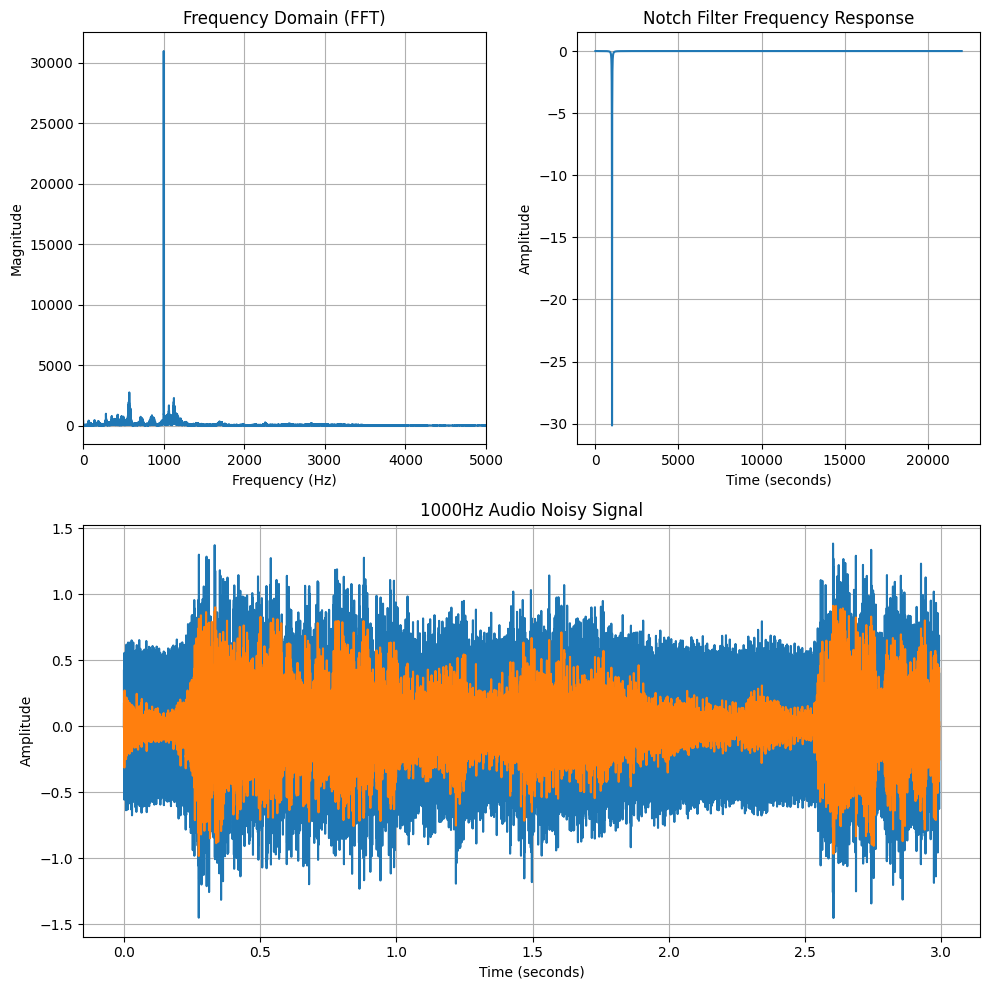

In [99]:
#Plot the signal
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(2, 2, 1)

ax1.plot(xf_positive, yf_positive)
ax1.set_title('Frequency Domain (FFT)')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude')
ax1.set_xlim(0, 5000)
ax1.grid(True)

ax2 = fig.add_subplot(2, 2, 2)

ax2.plot(frequencies, magnitude_db)
ax2.set_title('Notch Filter Frequency Response')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Amplitude')
ax2.grid(True)

ax3 = fig.add_subplot(2, 1, 2)

ax3.plot(t, noisy_signal)
ax3.plot(t, clean_signal)
ax3.set_title('1000Hz Audio Noisy Signal')
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('Amplitude')
ax3.grid(True)

fig.tight_layout()
plt.show()

#### Ex3 : LMS noise filtering
An adaptive line enhancer (ALE) is based on the straightforward concept of linear prediction. A nearly-periodic signal can be perfectly predicted using linear combinations of its past samples, whereas a non-periodic signal cannot. So, a delayed version of the measured signal s(n-D) is used as the reference input signal x(n) to the adaptive filter, and the desired response signal d(n) is made equal to s(n). The parameters to choose in such a system are the signal delay D and the filter length L used in the adaptive linear estimate. The amount of delay depends on the amount of correlation in the signal of interest. Since we don't have this signal, we shall just pick a value of D=100 and vary it later. Such a choice suggests that samples of the Hallelujah Chorus are uncorrelated if they are more than about 12 msec apart. Also, we'll choose a value of L=32 for the adaptive filter, although this too could be changed.

##### 3.1 : Design filter

- Select as input of the LMS the signal x delayed by Delay = 100 and the desired output the signal not delayed (x =xn(1:end-Delay), d = xn(Delay:end))
- Choose a LMS with 32 coefficients and a 
- Reconstruct the signal x by removing the estimated signal obtained with LMS filter

In [100]:
def myLMS(x, d, mu, p):
    """
    myLMS Adaptive filtering using the Widrow-Hoff LMS algorithm.

    Parameters:
        x    : 1D array, input data to the adaptive filter
        d    : 1D array, desired output
        mu   : float, LMS step-size (update) parameter
        p : int, number of filter coefficients

    Returns:
        W : 2D array of shape (N, nord), filter coefficients over time
        e : 1D array of shape (N,), error signal over time
    """
    N = len(x)
    w = np.zeros(p)
    e = np.zeros(N)
    W = np.zeros((N,p))

    for n in range (p,N):
        x_vec = x[n-p : n][::-1]          # [x(n-1), x(n-2), ..., x(n-p)]
        d_hat = w @ x_vec                 # prédiction
        e[n]  = d[n] - d_hat              # erreur
        w     = w + mu * e[n] * x_vec     # mise à jour
        W[n]  = w                         # historique


    return W, e

In [101]:
# 1. Set the LMS parameters
Delay = 100
p = 32         
mu = 0.001     # Step size (if the filter output is huge/explodes, make this smaller, like 0.0001)

# 2. Slice the noisy_signal to create the input and target
# x_input is the delayed reference
x_input = noisy_signal[:-Delay]  

# d_target is the current signal we want to predict
d_target = noisy_signal[Delay:]  

# 3. Run your LMS function
W, e = myLMS(x_input, d_target, mu, p)

# 4. The error 'e' is your reconstructed (clean) audio!
clean_signal_lms = e 

# 5. (Optional) Verify the result against your original signal_cut
# Note: Because we sliced off the first 100 samples of noisy_signal to make d_target,
# clean_signal_lms is 100 samples shorter than signal_cut. 
# To compare them properly, you also need to slice signal_cut!
original_to_compare = signal_cut[Delay:]

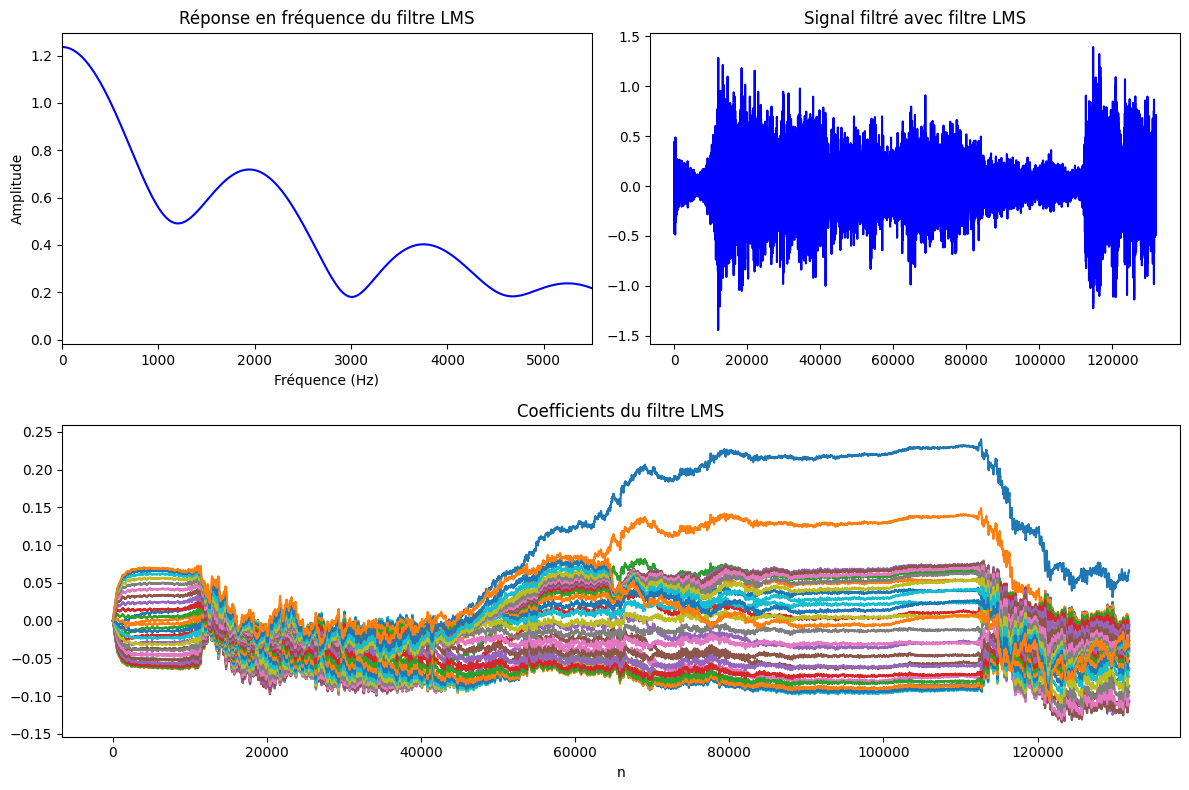

In [102]:
# W: Matrix of filter coefficients over time (Shape: N, 32)
# e: The error signal, which is our clean audio (Shape: N)
# fs: Sampling frequency (e.g., 44100 or whatever your audio uses)

fig = plt.figure(figsize=(12, 8))

# ---------------------------------------------------------
# 1. Top Left: Frequency Response of the FINAL LMS Filter
# ---------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)

# To get the frequency response, we look at the filter's state at the very end of the audio.
# We extract the last row of the weight matrix W (the final 32 coefficients)
w_final = W[-1, :] 

# Calculate frequency response (b = w_final, a = 1 because it's an FIR filter)
frequencies, response = signal.freqz(w_final, 1, worN=8000, fs=fs)

# Plot the amplitude (magnitude)
ax1.plot(frequencies, np.abs(response), color='blue')
ax1.set_title('Réponse en fréquence du filtre LMS')
ax1.set_xlabel('Fréquence (Hz)')
ax1.set_ylabel('Amplitude')
ax1.set_xlim(0, 5500) # Match your image's x-axis

# ---------------------------------------------------------
# 2. Top Right: The Filtered Signal (Clean Audio)
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)

# The filtered signal is simply 'e' (the error from the LMS)
ax2.plot(e, color='blue')
ax2.set_title('Signal filtré avec filtre LMS')
# No x/y labels in your image, but you can add them if you want!

# ---------------------------------------------------------
# 3. Bottom: The Evolution of the Filter Coefficients
# ---------------------------------------------------------
# using (2, 1, 2) makes this plot take up the entire bottom row
ax3 = plt.subplot(2, 1, 2) 

# W is a 2D array. If you pass a 2D array to plt.plot, 
# Matplotlib automatically plots every column as a separate line!
ax3.plot(W) 
ax3.set_title('Coefficients du filtre LMS')
ax3.set_xlabel('n')

# Adjust layout so titles don't overlap
plt.tight_layout()
plt.show()

#### Ex4 : FM Noise source

As seen, removing a pure sinusoid from a sinusoid plus music signal is not particularly challenging if the frequency of the offending sinusoid is known. So, let's make the problem a bit harder by adding an FM-modulated sinusoidal signal as our noise source.

$$
\text{noise}_{\text{fm}} = A \cdot \sin\left(2\pi f_0 t + \beta \sin(2\pi f_m t)\right)
$$

##### 4.1 : Generate the FM noise

- Generate a noise pfm(n) signal which is a FM-modulated sinusoidal with A = 0.5, f0=1000Hz, fm=1Hz, $\beta=600$
- Add this noise pfm(n) to the signal x(n) to create the new noisy signal sfm(n)
- Hear the signal

In [103]:
A_pfm = 0.5
f0_pfn = 1000
f_pfm = 1
beta_pfm = 600

noise_fm = A_pfm * np.sin((2 * np.pi * f0_pfn * t) + beta_pfm*np.sin(2*np.pi*f_pfm*t))
noisy_signal = signal_cut + noise_fm

In [104]:
# N is the length of your signal, fs is your sampling rate
N = len(noise_fm)

# 1. Calculate the FFT
yf = fft(noise_fm)

# 2. Calculate the corresponding frequencies
xf = fftfreq(N, 1/fs)
# 3. Take only the positive half of the frequencies
half_N = N // 2
xf_positive_noise = xf[:half_N]
yf_positive_noise = np.abs(yf[:half_N]) # Use absolute value to get magnitude

In [105]:
# N is the length of your signal, fs is your sampling rate
N = len(noisy_signal)

# 1. Calculate the FFT
yf = fft(noisy_signal)

# 2. Calculate the corresponding frequencies
xf = fftfreq(N, 1/fs)
# 3. Take only the positive half of the frequencies
half_N = N // 2
xf_positive_noisy = xf[:half_N]
yf_positive_noisy = np.abs(yf[:half_N]) # Use absolute value to get magnitude

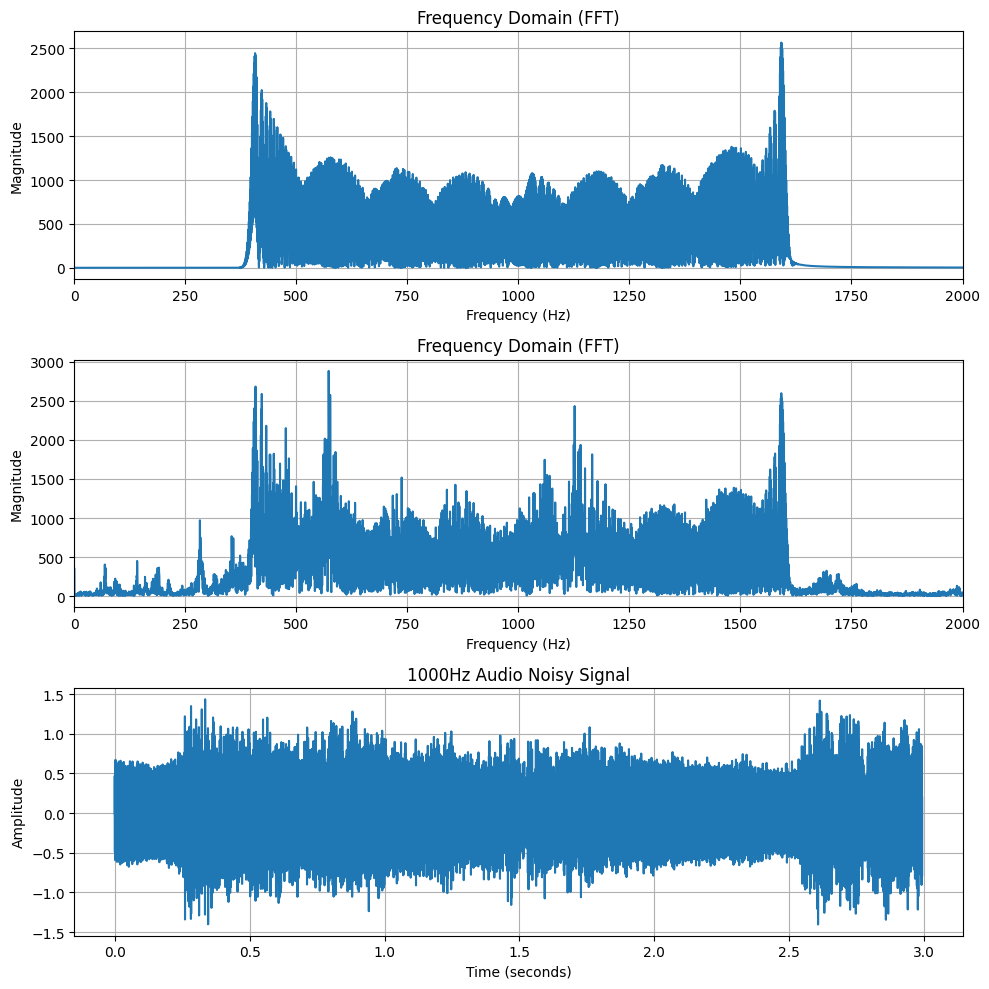

In [106]:
#Plot the signal
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(3, 1, 1)

ax1.plot(xf_positive_noise, yf_positive_noise)
ax1.set_title('Frequency Domain (FFT)')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude')
ax1.set_xlim(0, 2000)
ax1.grid(True)

ax2 = fig.add_subplot(3, 1, 2)

ax2.plot(xf_positive_noisy, yf_positive_noisy)
ax2.set_title('Frequency Domain (FFT)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.set_xlim(0, 2000)
ax2.grid(True)

ax3 = fig.add_subplot(3, 1, 3)

ax3.plot(t, noisy_signal)
ax3.set_title('1000Hz Audio Noisy Signal')
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('Amplitude')
ax3.grid(True)

fig.tight_layout()
plt.show()

##### 4.2 : Stop band filter

- Analyse the perturbation in the frequency domain
- Design a stopband filter with $fc = [f_0-\beta, f_0+\beta ]$ Hz
- Filter the signal with the stopband filter, display it and hear the filtered signal

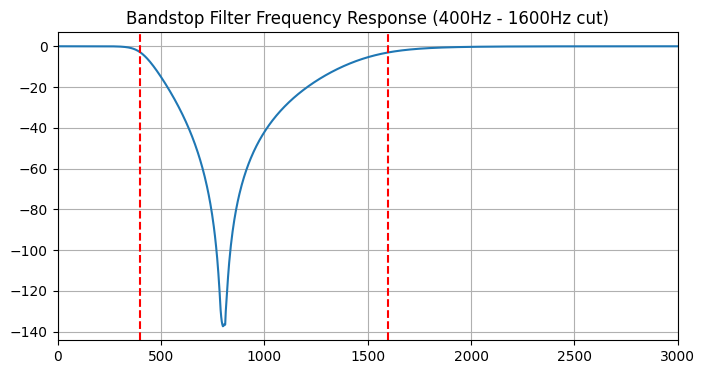

In [107]:
low_cut = f0_pfn - beta_pfm   # 400 Hz
high_cut = f0_pfn + beta_pfm  # 1600 Hz
cutoff_frequencies = [low_cut, high_cut]

# 2. Design the Butterworth Bandstop Filter
# N = Filter Order (4 is a safe default. Higher = sharper wall, but more distortion)
# btype='bandstop' tells it to kill the frequencies between our cutoffs
b, a = signal.butter(N=4, Wn=cutoff_frequencies, btype='bandstop', fs=fs)

# 3. Apply the filter to your noisy signal
clean_signal_stopband = signal.filtfilt(b, a, noisy_signal)

# 4. (Optional) Display the frequency response of the filter to prove it works
frequencies, response = signal.freqz(b, a, worN=8000, fs=fs)
plt.figure(figsize=(8, 4))
plt.plot(frequencies, 20 * np.log10(np.maximum(np.abs(response), 1e-10)))
plt.title('Bandstop Filter Frequency Response (400Hz - 1600Hz cut)')
plt.axvline(low_cut, color='red', linestyle='--')
plt.axvline(high_cut, color='red', linestyle='--')
plt.xlim(0, 3000)
plt.grid(True)
plt.show()

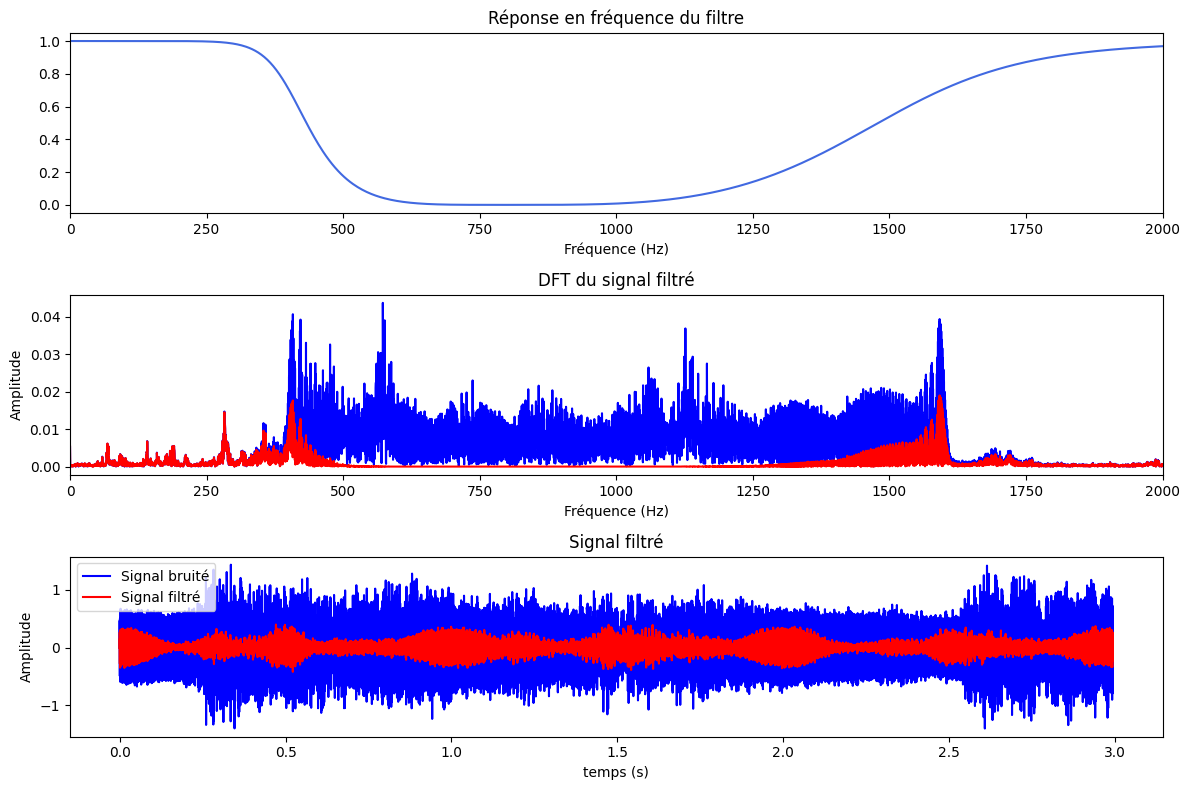

In [108]:
# Create a figure with 3 stacked plots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))

# ---------------------------------------------------------
# 1. Top Plot: Réponse en fréquence du filtre (Linear)
# ---------------------------------------------------------
frequencies, response = signal.freqz(b, a, worN=8000, fs=fs)

# Use absolute value for linear amplitude (0 to 1) instead of Decibels
ax1.plot(frequencies, np.abs(response), color='royalblue')
ax1.set_title('Réponse en fréquence du filtre')
ax1.set_xlabel('Fréquence (Hz)')
ax1.set_xlim(0, 2000)

# ---------------------------------------------------------
# 2. Middle Plot: DFT du signal filtré (Frequency Domain)
# ---------------------------------------------------------
N = len(noisy_signal)
xf = fftfreq(N, 1/fs)

# Calculate FFT magnitudes (Only taking the positive half up to N//2)
half_N = N // 2
xf_pos = xf[:half_N]

# We scale by 2/N to get the true linear amplitude of the waves
yf_noisy = (2.0 / N) * np.abs(fft(noisy_signal)[:half_N])
yf_clean = (2.0 / N) * np.abs(fft(clean_signal_stopband)[:half_N])

# Plot the noisy signal first (blue), then the clean signal on top (red)
ax2.plot(xf_pos, yf_noisy, color='blue', label='Signal bruité')
ax2.plot(xf_pos, yf_clean, color='red', label='Signal filtré')
ax2.set_title('DFT du signal filtré')
ax2.set_xlabel('Fréquence (Hz)')
ax2.set_ylabel('Amplitude')
ax2.set_xlim(0, 2000)

# ---------------------------------------------------------
# 3. Bottom Plot: Signal filtré (Time Domain)
# ---------------------------------------------------------
# Plot the noisy signal (blue), then the clean signal on top (red)
ax3.plot(t, noisy_signal, color='blue', label='Signal bruité')
ax3.plot(t, clean_signal_stopband, color='red', label='Signal filtré')
ax3.set_title('Signal filtré')
ax3.set_xlabel('temps (s)')
ax3.set_ylabel('Amplitude')

# Add the legend exactly where it is in the image (upper left)
ax3.legend(loc='upper left')

# Prevent labels from overlapping
plt.tight_layout()
plt.show()

##### 4.3 : LMS noise filtering

- Reconstruct the signal x by removing the estimated signal obtained with LMS filter ($\mu = 0.01$, p=32, Delay=100)
- Try to change the parameters of the LMS filter to see if you can improve the result
- Display the result and hear the filtered signal

In [109]:
# 1. Set the LMS parameters
Delay = 100
p = 32         
mu = 0.01     # Step size (if the filter output is huge/explodes, make this smaller, like 0.0001)

# 2. Slice the noisy_signal to create the input and target
# x_input is the delayed reference
x_input = noisy_signal[:-Delay]  

# d_target is the current signal we want to predict
d_target = noisy_signal[Delay:]  

# 3. Run your LMS function
W, e = myLMS(x_input, d_target, mu, p)

# 4. The error 'e' is your reconstructed (clean) audio!
clean_signal_lms = e 

# 5. (Optional) Verify the result against your original signal_cut
# Note: Because we sliced off the first 100 samples of noisy_signal to make d_target,
# clean_signal_lms is 100 samples shorter than signal_cut. 
# To compare them properly, you also need to slice signal_cut!
original_to_compare = signal_cut[Delay:]

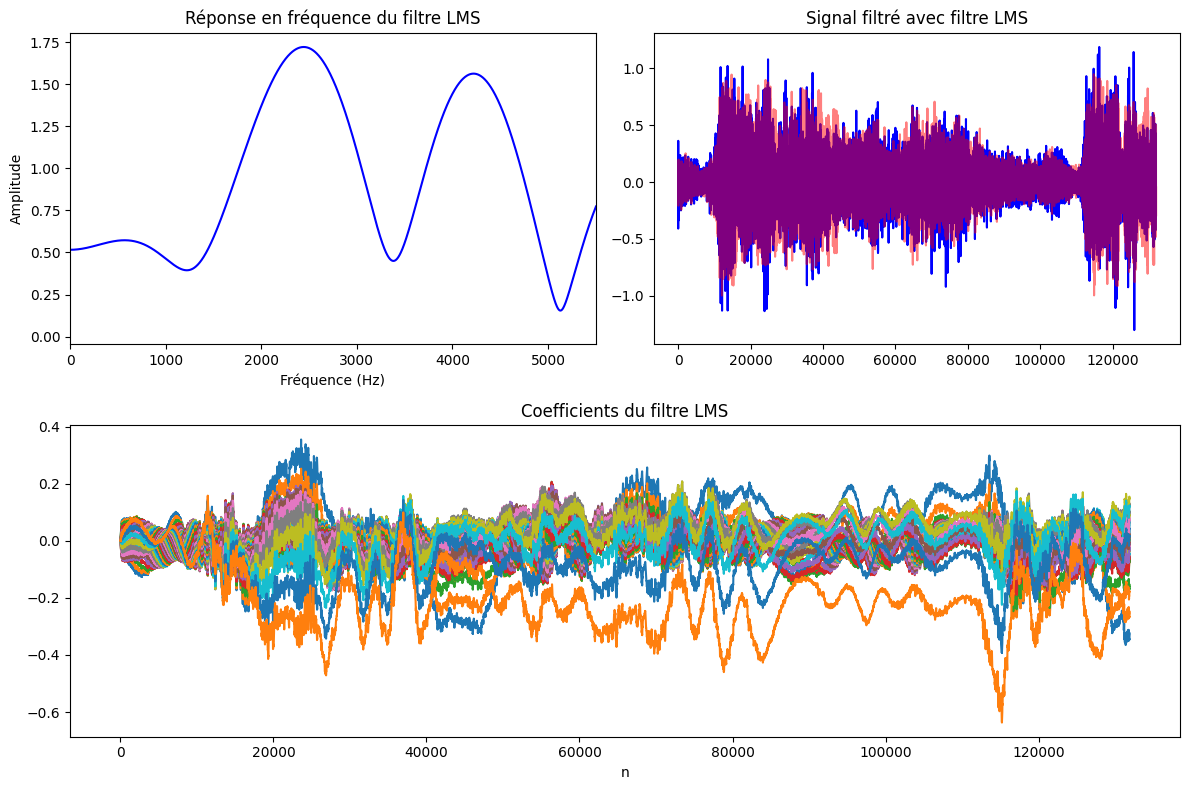

In [110]:
# W: Matrix of filter coefficients over time (Shape: N, 32)
# e: The error signal, which is our clean audio (Shape: N)
# fs: Sampling frequency (e.g., 44100 or whatever your audio uses)

fig = plt.figure(figsize=(12, 8))

# ---------------------------------------------------------
# 1. Top Left: Frequency Response of the FINAL LMS Filter
# ---------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)

# To get the frequency response, we look at the filter's state at the very end of the audio.
# We extract the last row of the weight matrix W (the final 32 coefficients)
w_final = W[-1, :] 

# Calculate frequency response (b = w_final, a = 1 because it's an FIR filter)
frequencies, response = signal.freqz(w_final, 1, worN=8000, fs=fs)

# Plot the amplitude (magnitude)
ax1.plot(frequencies, np.abs(response), color='blue')
ax1.set_title('Réponse en fréquence du filtre LMS')
ax1.set_xlabel('Fréquence (Hz)')
ax1.set_ylabel('Amplitude')
ax1.set_xlim(0, 5500) # Match your image's x-axis

# ---------------------------------------------------------
# 2. Top Right: The Filtered Signal (Clean Audio)
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)

# The filtered signal is simply 'e' (the error from the LMS)
ax2.plot(e, color='blue')
ax2.plot(signal_cut, color='red', alpha = 0.5)
ax2.set_title('Signal filtré avec filtre LMS')
# No x/y labels in your image, but you can add them if you want!

# ---------------------------------------------------------
# 3. Bottom: The Evolution of the Filter Coefficients
# ---------------------------------------------------------
# using (2, 1, 2) makes this plot take up the entire bottom row
ax3 = plt.subplot(2, 1, 2) 

# W is a 2D array. If you pass a 2D array to plt.plot, 
# Matplotlib automatically plots every column as a separate line!
ax3.plot(W) 
ax3.set_title('Coefficients du filtre LMS')
ax3.set_xlabel('n')

# Adjust layout so titles don't overlap
plt.tight_layout()
plt.show()